# Pixel vs. Webscrap — persona-blind VLM score analysis

Both logs come from the unlabeled-corpus (`persona_blind`) pipeline: every image is judged
`samples_per_image` times by `Qwen/Qwen2-VL-7B-Instruct` with the generic PARA system prompt, and the
model returns nine scores per sample on a **1–5** scale.

| | |
|---|---|
| `data/logs_t_0/pixel_result.json` | **pixel** corpus — 8,555 images x 8 samples |
| `data/logs_t_0/webscrap_check.json` | **webscrap** corpus — 100 images x 4 samples |

There is **no ground truth** in either log, so nothing here measures accuracy. "Better score" below
means *the model rates this corpus more highly*, not *the model is more right about it*.

The notebook does three things:

1. **Per-parameter score distributions for pixel** — one histogram per dimension, plus spread,
   self-consistency, and cross-dimension structure.
2. **The same for webscrap**, using the same functions.
3. **A head-to-head comparison** — which corpus the model scores higher, on which dimensions, by how
   much, and whether the gap survives a significance test.


In [3]:
import json
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# --- palette (validated categorical slots 1 & 2 + chart chrome) ---------------
PIXEL_C, WEB_C = "#2a78d6", "#1baf7a"        # blue, aqua
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
# correlation is signed -> diverging, gray at zero, never a rainbow
CORR_CMAP = LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": SECONDARY, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 10, "legend.fontsize": 9, "legend.frameon": False,
    "figure.dpi": 110, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.width", 160, "display.max_columns", 40)


## Loading

`images.<name>.scores.<dimension>` is the list of that image's per-sample scores. Flatten it to one
tidy row per (image, dimension, sample); drop the handful of `None`s left by unparseable responses.


In [4]:
LOG_DIR = Path("../data/logs_t_0")
LOGS = {"pixel": LOG_DIR / "pixel_result.json", "webscrap": LOG_DIR / "webscrap_check.json"}
COLORS = {"pixel": PIXEL_C, "webscrap": WEB_C}


def load_log(path):
    # -> (raw log dict, tidy DataFrame: one row per (image, dimension, sample))
    with open(path) as fh:
        log = json.load(fh)
    rows = [
        (name, dim, i, float(s))
        for name, entry in log["images"].items()
        for dim, scores in entry["scores"].items()
        for i, s in enumerate(scores)
        if s is not None
    ]
    df = pd.DataFrame(rows, columns=["image", "dimension", "sample", "score"])
    df["dimension"] = pd.Categorical(df["dimension"], categories=log["dimensions"], ordered=True)
    return log, df


logs, frames = {}, {}
for name, path in LOGS.items():
    logs[name], frames[name] = load_log(path)

DIMS = logs["pixel"]["dimensions"]
assert DIMS == logs["webscrap"]["dimensions"], "dimension sets differ; comparison below assumes they match"

meta = pd.DataFrame({
    name: {
        "images": log["n_images"], "samples/image": log["samples_per_image"], "responses": log["n_samples"],
        "model": log["model_name"], "temperature": log["temperature"],
        "top_k": log["top_k"], "top_p": log["top_p"],
        "persona_blind": log["persona_blind"], "generated_at": log["generated_at"][:19],
        "scores parsed": f"{len(frames[name]):,} / {log['n_samples'] * len(DIMS):,}",
    }
    for name, log in logs.items()
})
print("dimensions:", ", ".join(DIMS))
meta


dimensions: aestheticScore, qualityScore, compositionScore, colorScore, dofScore, contentScore, lightScore, contentPreference, willingnessToShare


,pixel,webscrap
images,8555,100
samples/image,8,4
responses,68440,400
model,Qwen/Qwen2-VL-7B-Instruct,Qwen/Qwen2-VL-7B-Instruct
temperature,0.7,0.7
top_k,0,0
top_p,1.0,1.0
persona_blind,True,True
generated_at,2026-07-11T09:47:11,2026-07-09T16:11:20
scores parsed,"615,861 / 615,960","3,597 / 3,600"


In [5]:
# Same prompt on both sides? If not, every downstream comparison is confounded.
same_sys = logs["pixel"]["system_prompt"] == logs["webscrap"]["system_prompt"]
same_q = logs["pixel"]["question"] == logs["webscrap"]["question"]
print(f"identical system prompt: {same_sys}\nidentical question:      {same_q}")
print("\n--- system prompt ---\n" + logs["pixel"]["system_prompt"])
print("\n--- question ---\n" + logs["pixel"]["question"])


identical system prompt: True
identical question:      True

--- system prompt ---
You are an impartial, general-purpose judge of photographic aesthetics.

You are shown one photograph from a photo-aesthetics rating study. Judge it on its own merits the way a typical viewer would, without adopting any particular person's perspective or taste. Not every photo deserves a good score; be honest when a photo is mediocre or disappointing. Do not mention that you are an AI.

--- question ---
Rate this photograph on each of the axes below. Judge each one honestly on its own merits, and use the full range instead of defaulting to the middle:
- "aestheticScore": overall aesthetic appeal (1 = very poor, 3 = average, 5 = excellent). Rate from 1 to 5 in steps of 0.5.
- "qualityScore": technical image quality — sharpness, exposure, noise and artifacts (1 = very low, 5 = flawless). Rate from 1 to 5 in steps of 0.1.
- "compositionScore": composition — framing, balance and use of space (1 = poor, 5 = e

## Shared analysis helpers

The unit of analysis is deliberately split in two, because the two levels answer different questions:

- **sample level** (every response) — what does the raw score distribution look like?
- **image level** (each image's mean across its samples) — how does the model separate *images*?

`within_std` is the model's average disagreement with *itself* on one image (decoding noise, since all
raters here are the same generic judge). `between_std` is the spread of per-image means. Their ratio is
the **discrimination ratio**: at or below 1 the model separates images no better than it contradicts
itself on a single image.


In [6]:
def per_image_means(df):
    # image x dimension matrix of each image's mean score
    return df.pivot_table(index="image", columns="dimension", values="score", aggfunc="mean", observed=True)


def summarise(df, log):
    # one row per dimension: pooled stats, noise decomposition, parse rate
    g = df.groupby("dimension", observed=True)["score"]
    img = df.groupby(["dimension", "image"], observed=True)["score"]
    out = pd.DataFrame({
        "n": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
        "within_std": img.std().groupby("dimension", observed=True).mean(),   # noise inside one image
        "between_std": img.mean().groupby("dimension", observed=True).std(),  # signal across images
    })
    out["discrimination"] = out["between_std"] / out["within_std"]
    out["parse_rate"] = pd.Series(
        {d: log["metrics"]["per_dimension"][d]["parse_rate"] for d in out.index}
    )
    return out


SCORE_BINS = np.arange(0.875, 5.30, 0.25)  # 0.25-wide bins centred on the 1..5 half-step grid


def plot_distributions(df, dims, color, title, bins=SCORE_BINS):
    # small multiples: proportion of samples at each score, one panel per dimension
    fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
    for ax, dim in zip(axes.flat, dims):
        s = df.loc[df["dimension"] == dim, "score"].to_numpy()
        w = np.ones_like(s) / len(s)
        ax.hist(s, bins=bins, weights=w, color=color, edgecolor=SURFACE, linewidth=0.8)
        ax.axvline(s.mean(), color=INK, linewidth=1.4, linestyle="--")
        ax.annotate(f"mean {s.mean():.2f}\nsd {s.std(ddof=1):.2f}", xy=(0.03, 0.93),
                    xycoords="axes fraction", va="top", fontsize=9, color=SECONDARY)
        ax.set_title(dim)
        ax.set_xlim(0.9, 5.2)
        ax.xaxis.grid(False)
    for ax in axes[-1]:
        ax.set_xlabel("score (1-5)")
    for ax in axes[:, 0]:
        ax.set_ylabel("share of samples")
    fig.suptitle(title, fontsize=14, fontweight="bold", color=INK, x=0.5, y=0.995)
    fig.tight_layout()
    plt.show()


def plot_discrimination(summary, color, title):
    # between-image sd vs within-image sd; left of the 1.0 line = no real discrimination
    s = summary.sort_values("discrimination")
    fig, ax = plt.subplots(figsize=(9, 4.2))
    y = np.arange(len(s))
    ax.barh(y, s["discrimination"], color=color, height=0.62)
    ax.axvline(1.0, color=CRITICAL, linewidth=1.6, linestyle="--")
    ax.annotate("parity: image spread = self-noise", xy=(1.0, len(s) - 0.4), xytext=(4, 0),
                textcoords="offset points", color=CRITICAL, fontsize=9, va="center")
    for yi, v in zip(y, s["discrimination"]):
        ax.annotate(f"{v:.2f}", xy=(v, yi), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=9, color=SECONDARY)
    ax.set_yticks(y, s.index)
    ax.set_xlabel("discrimination ratio  (between-image sd / within-image sd)")
    ax.set_xlim(0, max(1.35, s["discrimination"].max() * 1.18))
    ax.yaxis.grid(False)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def plot_corr(means, title):
    # Pearson r between per-image means; uniformly high r = the axes are one latent judgement
    corr = means.corr()
    fig, ax = plt.subplots(figsize=(7.6, 6.4))
    im = ax.imshow(corr, cmap=CORR_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr)), corr.index)
    for i in range(len(corr)):
        for j in range(len(corr)):
            v = corr.iat[i, j]
            ax.annotate(f"{v:.2f}", (j, i), ha="center", va="center", fontsize=8,
                        color="#ffffff" if abs(v) > 0.62 else INK)
    ax.grid(False)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r  (per-image means)")
    fig.tight_layout()
    plt.show()
    return corr


# 1. Pixel corpus


In [7]:
pixel_df = frames["pixel"]
pixel_means = per_image_means(pixel_df)
pixel_summary = summarise(pixel_df, logs["pixel"])
pixel_summary.round(3)


,n,mean,sd,median,min,max,within_std,between_std,discrimination,parse_rate
dimension,,,,,,,,,,
aestheticScore,68437,4.130,0.548,4.0,1.0,5.0,0.358,0.412,1.149,1.000
qualityScore,68437,4.415,0.489,4.5,1.0,5.0,0.277,0.397,1.434,1.000
compositionScore,68437,4.249,0.723,4.0,1.0,5.0,0.553,0.465,0.841,1.000
colorScore,68437,4.154,0.933,4.0,1.0,5.0,0.541,0.712,1.316,1.000
dofScore,68435,4.320,0.688,4.0,1.0,5.0,0.510,0.460,0.902,1.000
contentScore,68437,4.154,0.741,4.0,1.0,5.0,0.544,0.507,0.932,1.000
lightScore,68436,4.292,0.733,4.0,1.0,5.0,0.483,0.541,1.119,1.000
contentPreference,68436,4.316,0.755,4.0,1.0,5.0,0.554,0.498,0.899,1.000
willingnessToShare,68369,4.345,0.694,4.0,1.0,5.0,0.496,0.477,0.960,0.999


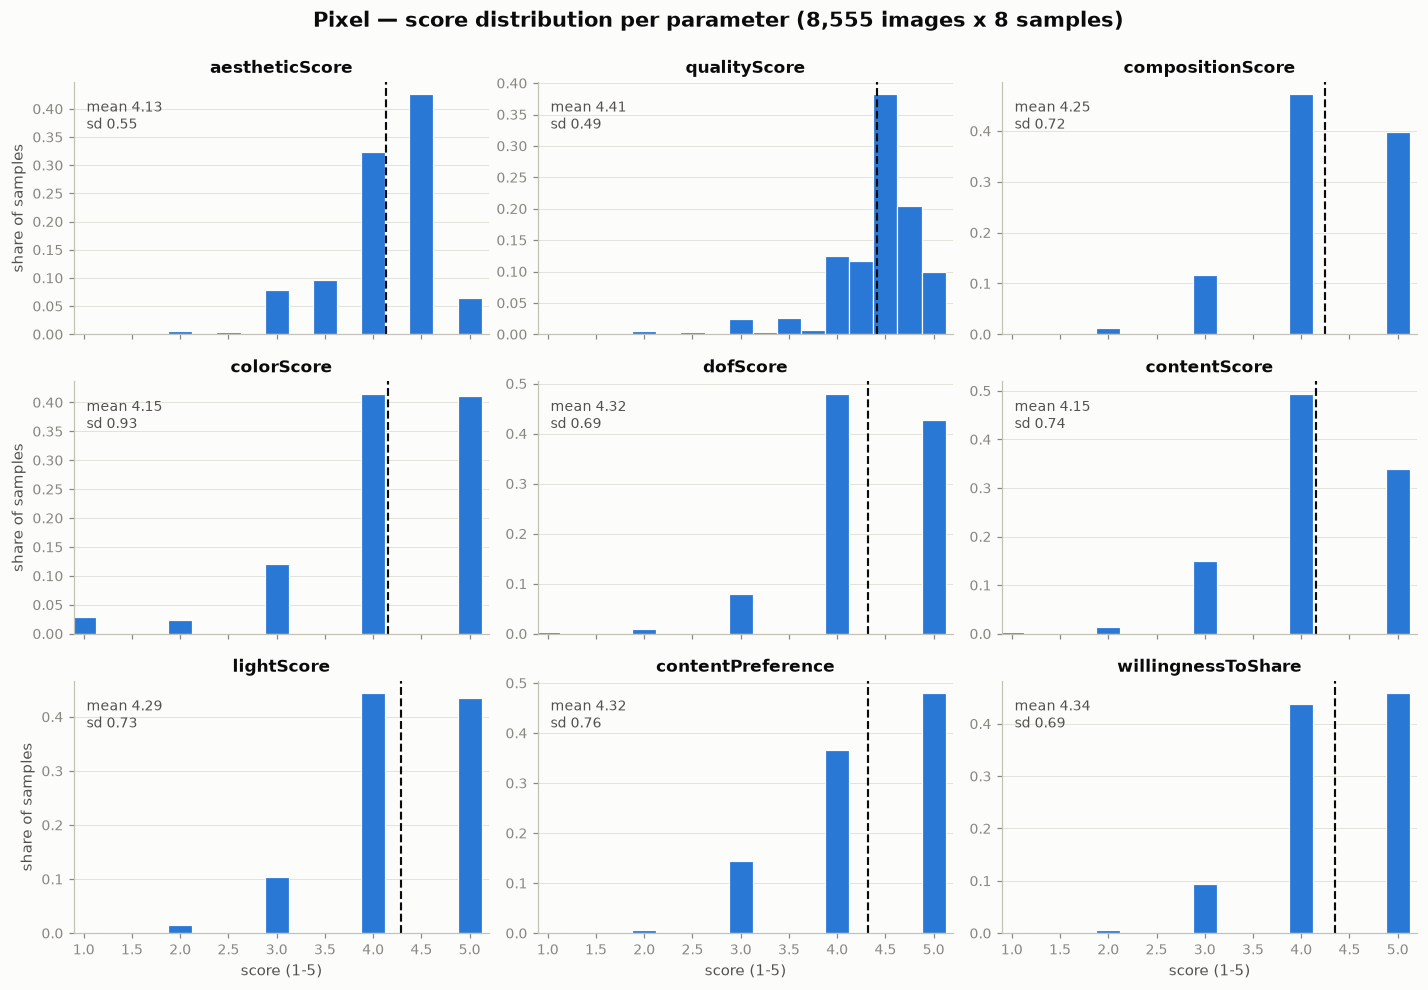

In [8]:
plot_distributions(pixel_df, DIMS, PIXEL_C, "Pixel — score distribution per parameter (8,555 images x 8 samples)")


Averaging an image's samples strips out most decoding noise, so the per-image means show what the model
actually thinks image-to-image. A tight column here means the model gives nearly every image the same
verdict on that axis.


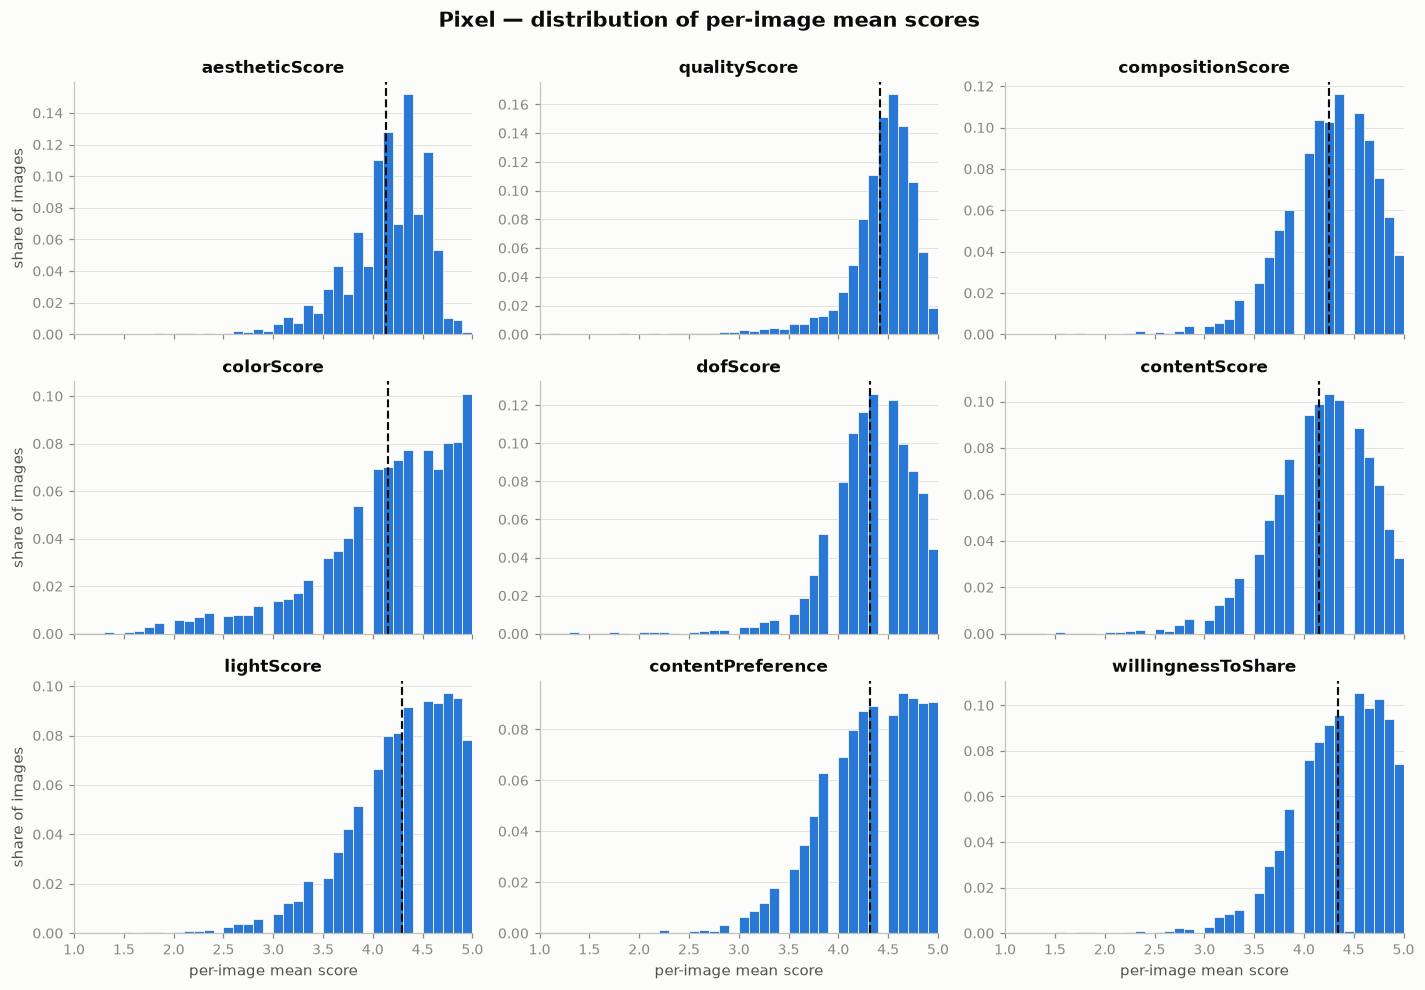

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
for ax, dim in zip(axes.flat, DIMS):
    m = pixel_means[dim].to_numpy()
    ax.hist(m, bins=np.linspace(1, 5, 41), color=PIXEL_C, edgecolor=SURFACE, linewidth=0.5,
            weights=np.ones_like(m) / len(m))
    ax.axvline(m.mean(), color=INK, linewidth=1.4, linestyle="--")
    ax.set_title(dim)
    ax.set_xlim(1, 5)
    ax.xaxis.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("per-image mean score")
for ax in axes[:, 0]:
    ax.set_ylabel("share of images")
fig.suptitle("Pixel — distribution of per-image mean scores", fontsize=14, fontweight="bold", color=INK, y=0.995)
fig.tight_layout()
plt.show()


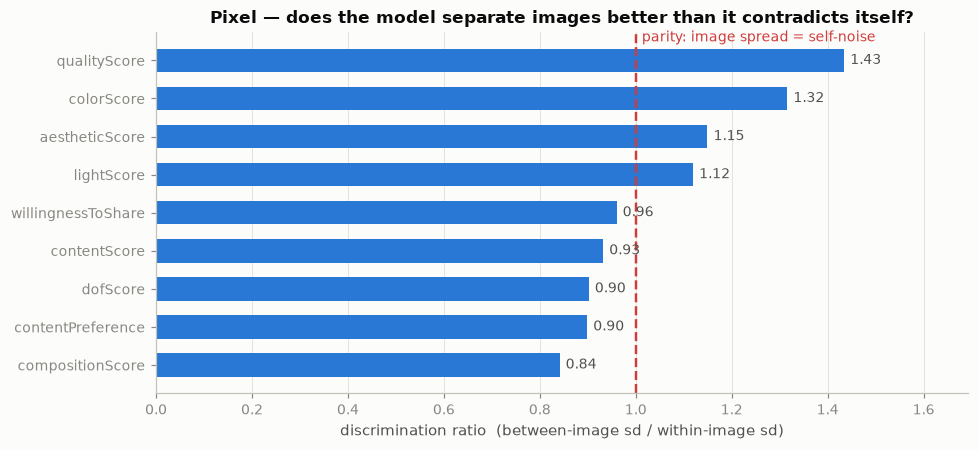

In [10]:
plot_discrimination(pixel_summary, PIXEL_C, "Pixel — does the model separate images better than it contradicts itself?")


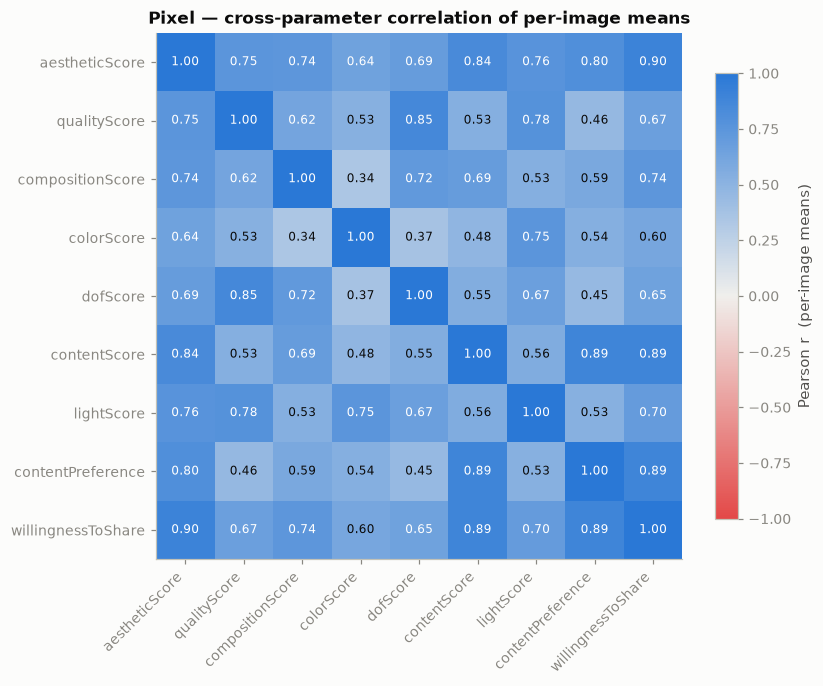

off-diagonal r: mean 0.66, min 0.34, max 0.90


In [11]:
pixel_corr = plot_corr(pixel_means, "Pixel — cross-parameter correlation of per-image means")
off_diag = pixel_corr.to_numpy()[np.triu_indices(len(pixel_corr), k=1)]
print(f"off-diagonal r: mean {off_diag.mean():.2f}, min {off_diag.min():.2f}, max {off_diag.max():.2f}")


# 2. Webscrap corpus

Same code, same axes, 100 images x 4 samples.


In [12]:
web_df = frames["webscrap"]
web_means = per_image_means(web_df)
web_summary = summarise(web_df, logs["webscrap"])
web_summary.round(3)


,n,mean,sd,median,min,max,within_std,between_std,discrimination,parse_rate
dimension,,,,,,,,,,
aestheticScore,400,4.440,0.468,4.50,2.0,5.0,0.282,0.357,1.268,1.000
qualityScore,400,4.630,0.327,4.75,3.0,5.0,0.219,0.241,1.102,1.000
compositionScore,400,4.465,0.596,5.00,3.0,5.0,0.379,0.441,1.164,1.000
colorScore,400,4.698,0.507,5.00,3.0,5.0,0.263,0.377,1.430,1.000
dofScore,400,4.512,0.601,5.00,2.0,5.0,0.426,0.409,0.959,1.000
contentScore,400,4.488,0.633,5.00,2.0,5.0,0.381,0.473,1.243,1.000
lightScore,400,4.732,0.491,5.00,3.0,5.0,0.258,0.368,1.425,1.000
contentPreference,400,4.655,0.597,5.00,2.0,5.0,0.352,0.409,1.164,1.000
willingnessToShare,397,4.673,0.554,5.00,2.0,5.0,0.310,0.390,1.258,0.992


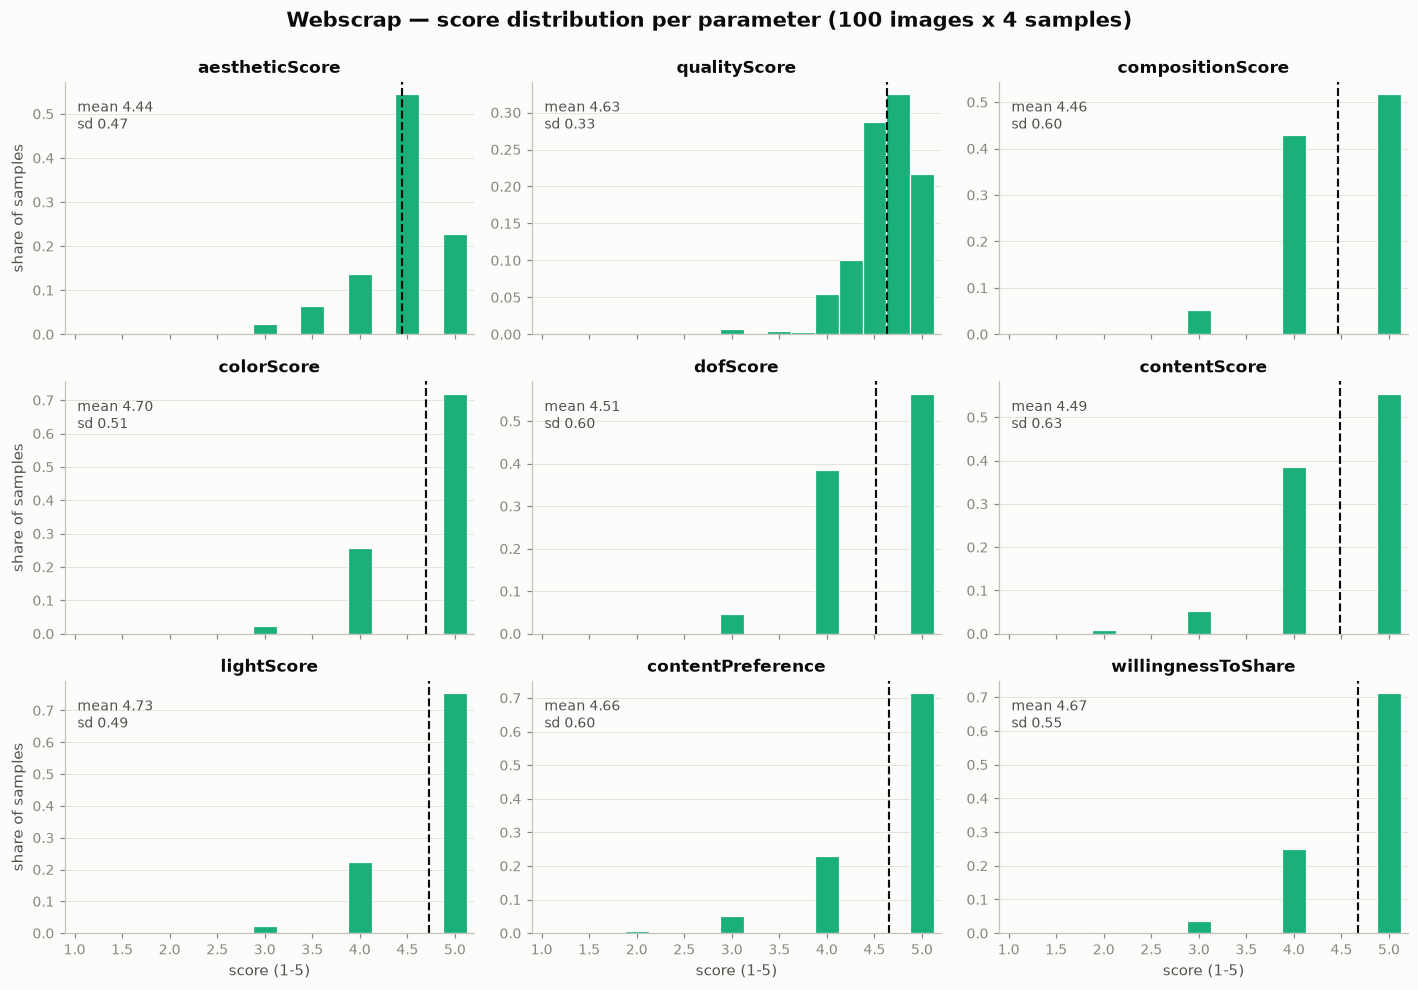

In [23]:
plot_distributions(web_df, DIMS, WEB_C, "Webscrap — score distribution per parameter (100 images x 4 samples)")


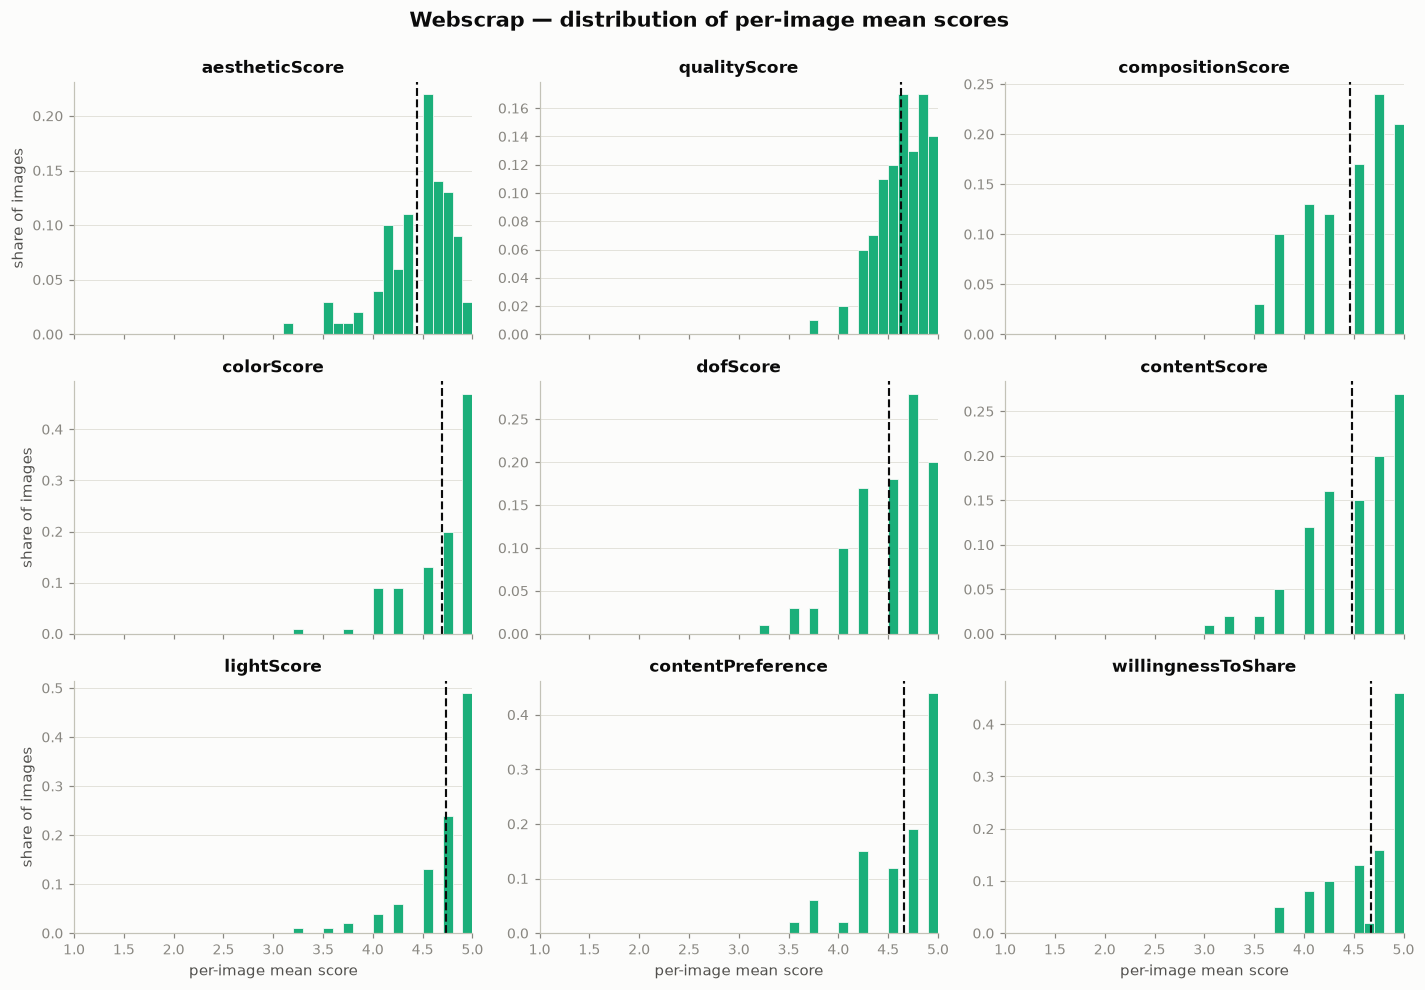

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
for ax, dim in zip(axes.flat, DIMS):
    m = web_means[dim].to_numpy()
    ax.hist(m, bins=np.linspace(1, 5, 41), color=WEB_C, edgecolor=SURFACE, linewidth=0.5,
            weights=np.ones_like(m) / len(m))
    ax.axvline(m.mean(), color=INK, linewidth=1.4, linestyle="--")
    ax.set_title(dim)
    ax.set_xlim(1, 5)
    ax.xaxis.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("per-image mean score")
for ax in axes[:, 0]:
    ax.set_ylabel("share of images")
fig.suptitle("Webscrap — distribution of per-image mean scores", fontsize=14, fontweight="bold", color=INK, y=0.995)
fig.tight_layout()
plt.show()


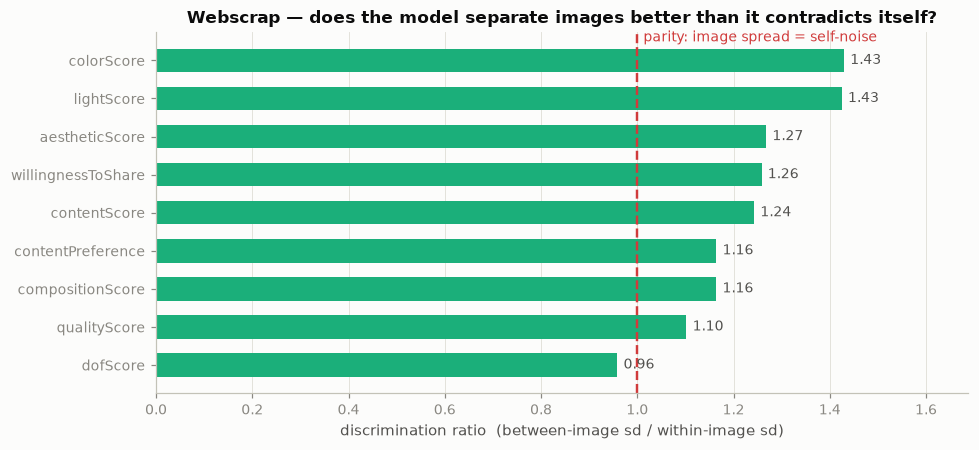

In [15]:
plot_discrimination(web_summary, WEB_C, "Webscrap — does the model separate images better than it contradicts itself?")


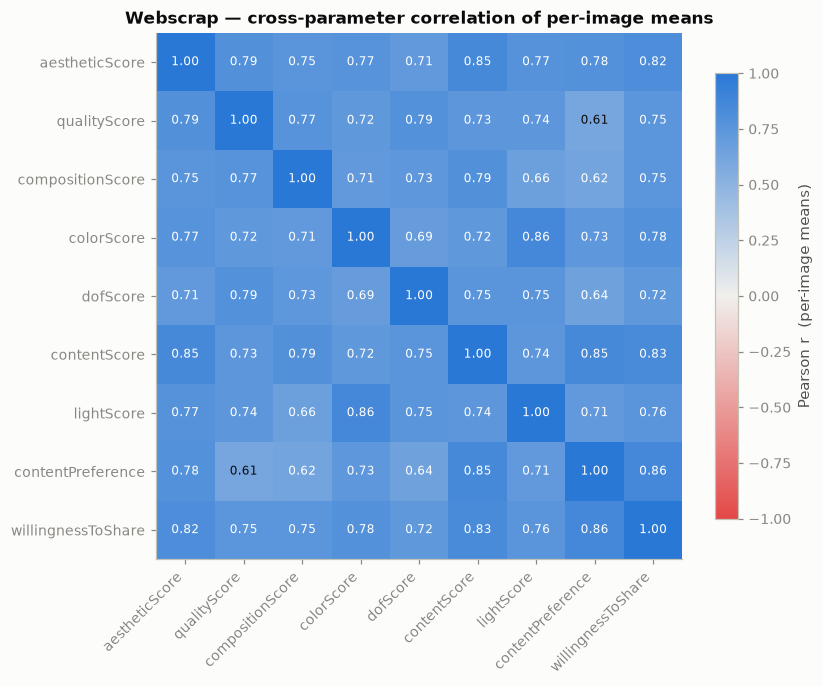

off-diagonal r: mean 0.75, min 0.61, max 0.86


In [16]:
web_corr = plot_corr(web_means, "Webscrap — cross-parameter correlation of per-image means")
off_diag_w = web_corr.to_numpy()[np.triu_indices(len(web_corr), k=1)]
print(f"off-diagonal r: mean {off_diag_w.mean():.2f}, min {off_diag_w.min():.2f}, max {off_diag_w.max():.2f}")


# 3. Head-to-head

The comparison is done on **per-image means** (n = 8,555 vs n = 100), not on raw samples: repeated
samples of one image are not independent observations, so pooling them would inflate n by the sample
count and make every difference look significant.

Per dimension:

- **delta** = webscrap mean − pixel mean (positive = the model likes webscrap more)
- **Welch t-test** on the two sets of per-image means (unequal variance, unequal n)
- **Mann-Whitney U**, and **Cliff's delta** as its effect size — the probability that a random webscrap
  image outscores a random pixel image, rescaled to −1..+1 (|d| < 0.15 negligible, < 0.33 small,
  < 0.47 medium, else large)
- **EMD** — Wasserstein distance between the two per-image-mean distributions, in score points


In [17]:
def compare(dim):
    a = pixel_means[dim].dropna().to_numpy()   # pixel
    b = web_means[dim].dropna().to_numpy()     # webscrap
    t, p_t = stats.ttest_ind(b, a, equal_var=False)
    u, p_u = stats.mannwhitneyu(b, a, alternative="two-sided")
    cliffs = 2 * u / (len(a) * len(b)) - 1     # rank-biserial == Cliff's delta
    return {
        "pixel_mean": a.mean(), "web_mean": b.mean(), "delta": b.mean() - a.mean(),
        "pixel_sd": a.std(ddof=1), "web_sd": b.std(ddof=1),
        "welch_p": p_t, "mwu_p": p_u, "cliffs_delta": cliffs,
        "emd": stats.wasserstein_distance(a, b),
    }


def label_effect(d):
    a = abs(d)
    return "negligible" if a < 0.147 else "small" if a < 0.33 else "medium" if a < 0.474 else "large"


cmp = pd.DataFrame({d: compare(d) for d in DIMS}).T
cmp.index.name = "dimension"
cmp["winner"] = np.where(cmp["delta"] > 0, "webscrap", "pixel")
cmp["effect"] = cmp["cliffs_delta"].map(label_effect)
cmp["sig(.05)"] = np.where(cmp["mwu_p"] < 0.05, "yes", "no")
cmp.round(4)


,pixel_mean,web_mean,delta,pixel_sd,web_sd,welch_p,mwu_p,cliffs_delta,emd,winner,effect,sig(.05)
dimension,,,,,,,,,,,,
aestheticScore,4.1298,4.4400,0.3102,0.4120,0.3573,0.0,0.0,0.4756,0.3102,webscrap,large,yes
qualityScore,4.4146,4.6298,0.2152,0.3967,0.2412,0.0,0.0,0.3806,0.2152,webscrap,medium,yes
compositionScore,4.2492,4.4650,0.2158,0.4653,0.4410,0.0,0.0,0.2688,0.2158,webscrap,small,yes
colorScore,4.1539,4.6975,0.5436,0.7120,0.3765,0.0,0.0,0.5206,0.5436,webscrap,large,yes
dofScore,4.3198,4.5125,0.1927,0.4604,0.4088,0.0,0.0,0.2667,0.1927,webscrap,small,yes
contentScore,4.1540,4.4875,0.3335,0.5066,0.4732,0.0,0.0,0.3900,0.3335,webscrap,medium,yes
lightScore,4.2922,4.7325,0.4403,0.5407,0.3680,0.0,0.0,0.5469,0.4403,webscrap,large,yes
contentPreference,4.3164,4.6550,0.3386,0.4981,0.4095,0.0,0.0,0.4281,0.3386,webscrap,medium,yes
willingnessToShare,4.3449,4.6708,0.3259,0.4766,0.3902,0.0,0.0,0.4356,0.3259,webscrap,medium,yes


### Where each corpus lands, dimension by dimension

A dumbbell chart, not two bar charts: the quantity of interest is the *gap* between two means on a
shared 1–5 scale, and a dumbbell puts that gap on the page as a line you can read directly.


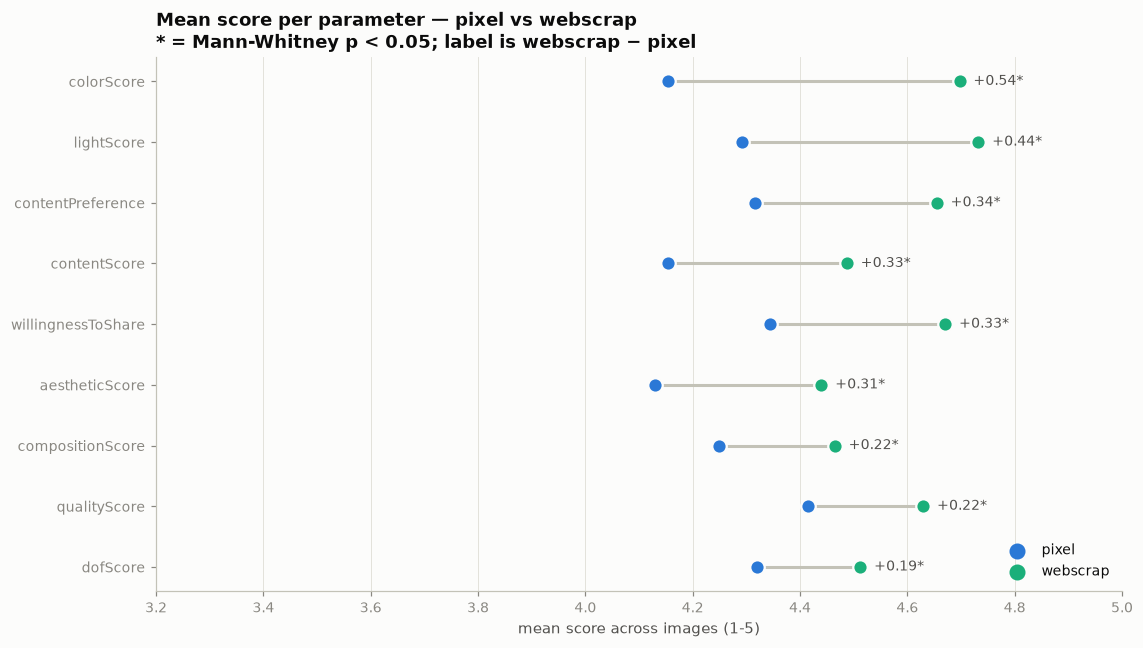

In [18]:
order = cmp["delta"].sort_values().index
fig, ax = plt.subplots(figsize=(10.5, 6))
y = np.arange(len(order))
for yi, dim in zip(y, order):
    p, w = cmp.loc[dim, "pixel_mean"], cmp.loc[dim, "web_mean"]
    ax.plot([p, w], [yi, yi], color=BASELINE, linewidth=2, zorder=1, solid_capstyle="round")
    ax.scatter([p], [yi], s=90, color=PIXEL_C, zorder=2, edgecolor=SURFACE, linewidth=1.5)
    ax.scatter([w], [yi], s=90, color=WEB_C, zorder=2, edgecolor=SURFACE, linewidth=1.5)
    d = cmp.loc[dim, "delta"]
    star = "*" if cmp.loc[dim, "mwu_p"] < 0.05 else ""
    ax.annotate(f"{d:+.2f}{star}", xy=(max(p, w), yi), xytext=(9, 0), textcoords="offset points",
                va="center", fontsize=9, color=SECONDARY)
ax.scatter([], [], s=90, color=PIXEL_C, label="pixel")
ax.scatter([], [], s=90, color=WEB_C, label="webscrap")
ax.set_yticks(y, order)
ax.set_xlabel("mean score across images (1-5)")
ax.set_xlim(3.2, 5.0)
ax.yaxis.grid(False)
ax.legend(loc="lower right")
ax.set_title("Mean score per parameter — pixel vs webscrap\n* = Mann-Whitney p < 0.05; label is webscrap − pixel",
             fontsize=12, loc="left")
fig.tight_layout()
plt.show()


### Full distributions, overlaid

Means hide shape. These are the per-image-mean distributions on a shared axis — a shifted corpus and a
merely *wider* corpus produce the same delta but look nothing alike here.


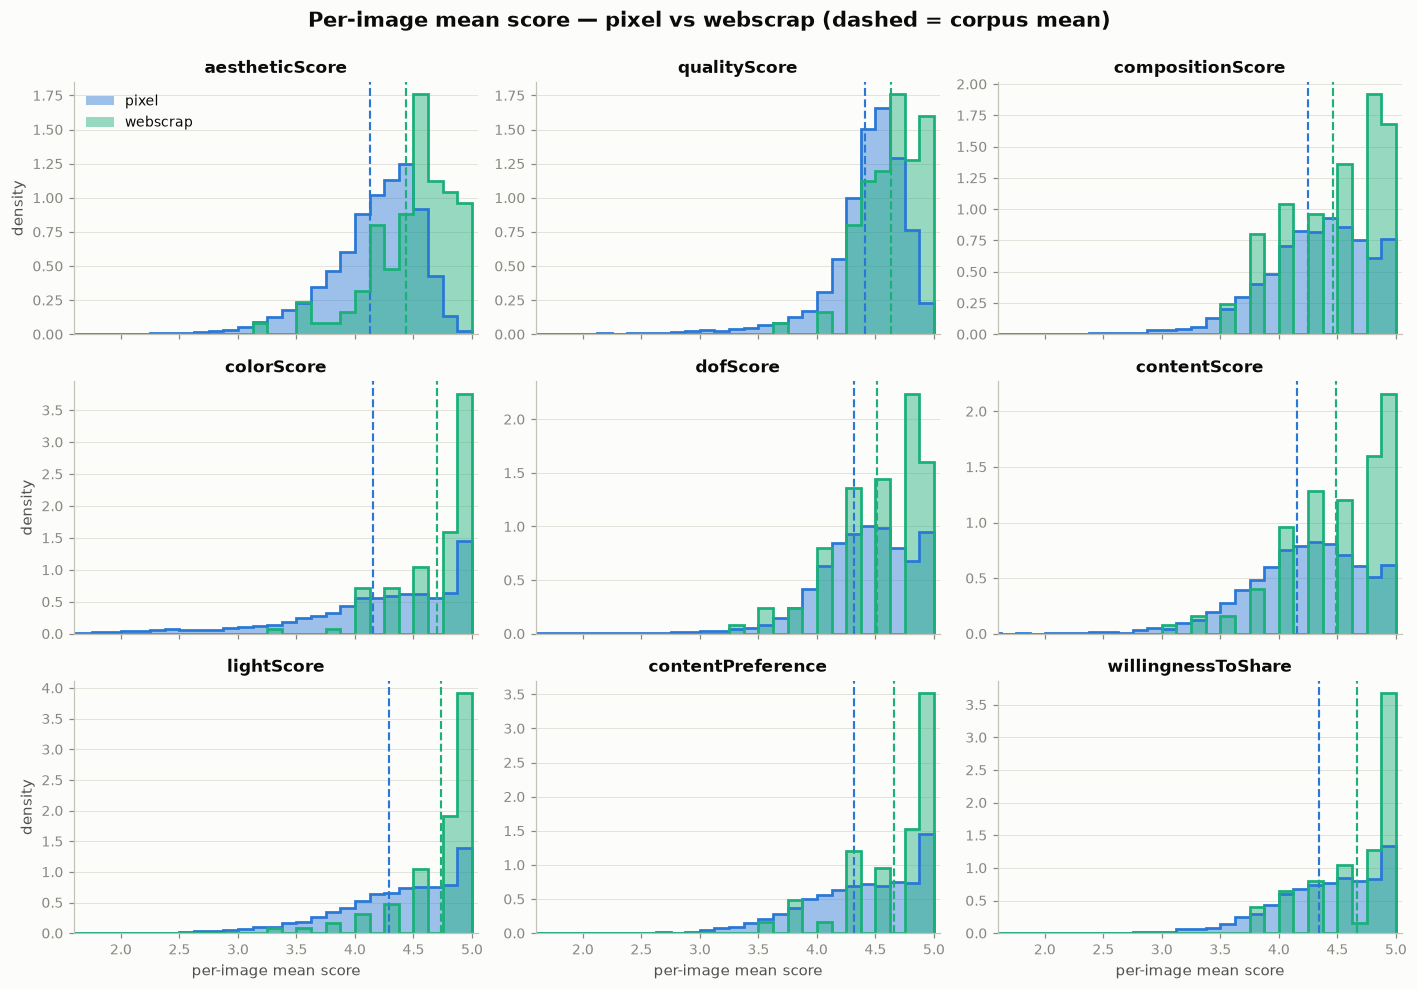

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
bins = np.linspace(1, 5, 33)
for ax, dim in zip(axes.flat, DIMS):
    for key, means, color in (("pixel", pixel_means, PIXEL_C), ("webscrap", web_means, WEB_C)):
        m = means[dim].dropna().to_numpy()
        ax.hist(m, bins=bins, density=True, color=color, alpha=0.45, label=key)
        ax.hist(m, bins=bins, density=True, histtype="step", color=color, linewidth=1.8)
        ax.axvline(m.mean(), color=color, linestyle="--", linewidth=1.4)
    ax.set_title(dim)
    ax.set_xlim(1.6, 5.05)
    ax.xaxis.grid(False)
for ax in axes[-1]:
    ax.set_xlabel("per-image mean score")
for ax in axes[:, 0]:
    ax.set_ylabel("density")
axes[0, 0].legend(loc="upper left")
fig.suptitle("Per-image mean score — pixel vs webscrap (dashed = corpus mean)",
             fontsize=14, fontweight="bold", color=INK, y=0.995)
fig.tight_layout()
plt.show()


### Spread and self-consistency

A higher mean is only worth something if the model is also *discriminating* — separating images rather
than repeating one verdict. Same discrimination ratio as above, now side by side.


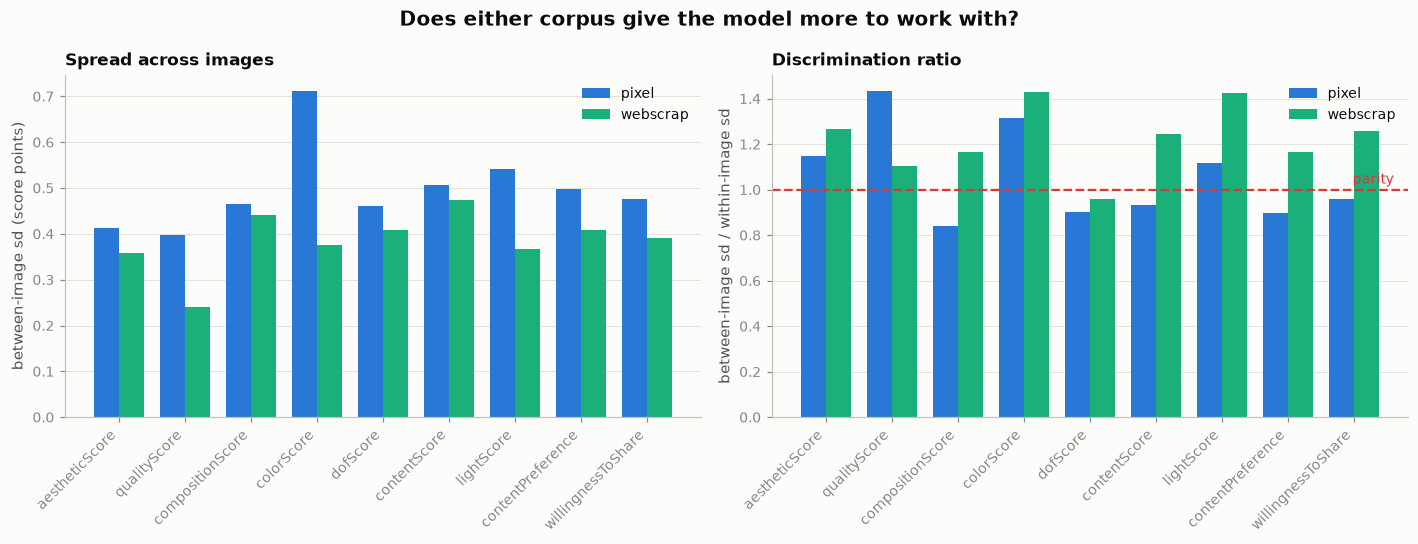

,pixel_within_sd,web_within_sd,pixel_between_sd,web_between_sd,pixel_discrim,web_discrim
dimension,,,,,,
aestheticScore,0.358,0.282,0.412,0.357,1.149,1.268
qualityScore,0.277,0.219,0.397,0.241,1.434,1.102
compositionScore,0.553,0.379,0.465,0.441,0.841,1.164
colorScore,0.541,0.263,0.712,0.377,1.316,1.430
dofScore,0.510,0.426,0.460,0.409,0.902,0.959
contentScore,0.544,0.381,0.507,0.473,0.932,1.243
lightScore,0.483,0.258,0.541,0.368,1.119,1.425
contentPreference,0.554,0.352,0.498,0.409,0.899,1.164
willingnessToShare,0.496,0.310,0.477,0.390,0.960,1.258


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(DIMS))
width = 0.38

ax = axes[0]
ax.bar(x - width / 2, pixel_summary.loc[DIMS, "between_std"], width, color=PIXEL_C, label="pixel")
ax.bar(x + width / 2, web_summary.loc[DIMS, "between_std"], width, color=WEB_C, label="webscrap")
ax.set_xticks(x, DIMS, rotation=45, ha="right")
ax.set_ylabel("between-image sd (score points)")
ax.set_title("Spread across images", loc="left")
ax.xaxis.grid(False)
ax.legend()

ax = axes[1]
ax.bar(x - width / 2, pixel_summary.loc[DIMS, "discrimination"], width, color=PIXEL_C, label="pixel")
ax.bar(x + width / 2, web_summary.loc[DIMS, "discrimination"], width, color=WEB_C, label="webscrap")
ax.axhline(1.0, color=CRITICAL, linewidth=1.5, linestyle="--")
ax.annotate("parity", xy=(len(DIMS) - 0.4, 1.0), xytext=(0, 4), textcoords="offset points",
            color=CRITICAL, fontsize=9, ha="right")
ax.set_xticks(x, DIMS, rotation=45, ha="right")
ax.set_ylabel("between-image sd / within-image sd")
ax.set_title("Discrimination ratio", loc="left")
ax.xaxis.grid(False)
ax.legend()

fig.suptitle("Does either corpus give the model more to work with?", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

spread = pd.DataFrame({
    "pixel_within_sd": pixel_summary["within_std"], "web_within_sd": web_summary["within_std"],
    "pixel_between_sd": pixel_summary["between_std"], "web_between_sd": web_summary["between_std"],
    "pixel_discrim": pixel_summary["discrimination"], "web_discrim": web_summary["discrimination"],
}).round(3)
spread


### Verdict


In [21]:
web_wins = cmp[(cmp["delta"] > 0) & (cmp["mwu_p"] < 0.05)].index.tolist()
pix_wins = cmp[(cmp["delta"] < 0) & (cmp["mwu_p"] < 0.05)].index.tolist()
ties = [d for d in DIMS if d not in web_wins + pix_wins]

overall_pixel = pixel_means[DIMS].mean(axis=1)   # each image's mean across all nine axes
overall_web = web_means[DIMS].mean(axis=1)
u, p_overall = stats.mannwhitneyu(overall_web, overall_pixel, alternative="two-sided")
cliffs_overall = 2 * u / (len(overall_pixel) * len(overall_web)) - 1

print(f"Overall composite (mean of all 9 axes per image)")
print(f"  pixel     {overall_pixel.mean():.3f}  (sd {overall_pixel.std():.3f}, n={len(overall_pixel):,})")
print(f"  webscrap  {overall_web.mean():.3f}  (sd {overall_web.std():.3f}, n={len(overall_web):,})")
print(f"  delta     {overall_web.mean() - overall_pixel.mean():+.3f}   Mann-Whitney p = {p_overall:.3g}"
      f"   Cliff's delta = {cliffs_overall:+.3f} ({label_effect(cliffs_overall)})")
print()
print(f"Significantly higher on webscrap ({len(web_wins)}/9): {', '.join(web_wins) or 'none'}")
print(f"Significantly higher on pixel    ({len(pix_wins)}/9): {', '.join(pix_wins) or 'none'}")
print(f"No significant difference        ({len(ties)}/9): {', '.join(ties) or 'none'}")
print()
print(f"Aesthetic axis only: pixel {cmp.loc['aestheticScore', 'pixel_mean']:.3f} vs "
      f"webscrap {cmp.loc['aestheticScore', 'web_mean']:.3f} "
      f"(delta {cmp.loc['aestheticScore', 'delta']:+.3f}, "
      f"{label_effect(cmp.loc['aestheticScore', 'cliffs_delta'])} effect)")
print(f"Mean discrimination ratio: pixel {pixel_summary['discrimination'].mean():.2f} vs "
      f"webscrap {web_summary['discrimination'].mean():.2f}")
print(f"Mean off-diagonal cross-axis r: pixel {off_diag.mean():.2f} vs webscrap {off_diag_w.mean():.2f}")


Overall composite (mean of all 9 axes per image)
  pixel     4.264  (sd 0.411, n=8,555)
  webscrap  4.588  (sd 0.340, n=100)
  delta     +0.324   Mann-Whitney p = 3.04e-17   Cliff's delta = +0.490 (large)

Significantly higher on webscrap (9/9): aestheticScore, qualityScore, compositionScore, colorScore, dofScore, contentScore, lightScore, contentPreference, willingnessToShare
Significantly higher on pixel    (0/9): none
No significant difference        (0/9): none

Aesthetic axis only: pixel 4.130 vs webscrap 4.440 (delta +0.310, large effect)
Mean discrimination ratio: pixel 1.06 vs webscrap 1.22
Mean off-diagonal cross-axis r: pixel 0.66 vs webscrap 0.75


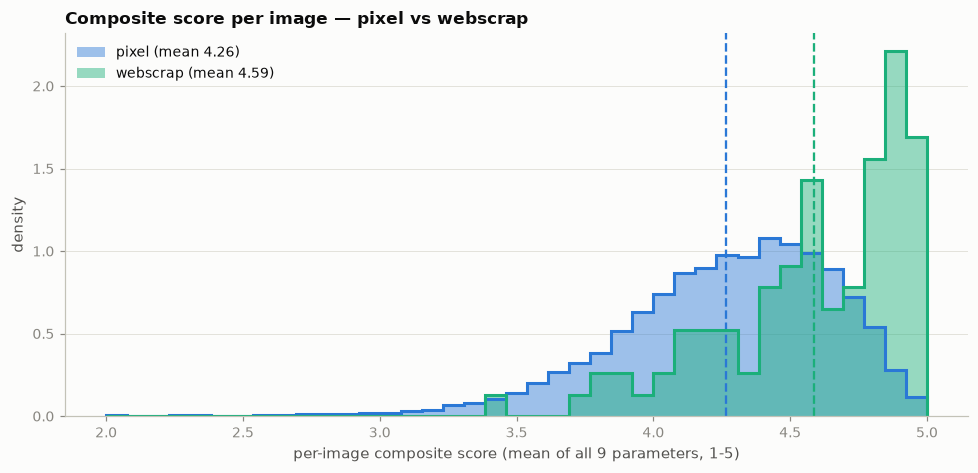

In [22]:
# Composite score, side by side — the headline in one picture.
fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.linspace(2, 5, 40)
for key, s, color in (("pixel", overall_pixel, PIXEL_C), ("webscrap", overall_web, WEB_C)):
    ax.hist(s, bins=bins, density=True, color=color, alpha=0.45, label=f"{key} (mean {s.mean():.2f})")
    ax.hist(s, bins=bins, density=True, histtype="step", color=color, linewidth=2)
    ax.axvline(s.mean(), color=color, linestyle="--", linewidth=1.5)
ax.set_xlabel("per-image composite score (mean of all 9 parameters, 1-5)")
ax.set_ylabel("density")
ax.xaxis.grid(False)
ax.legend(loc="upper left")
ax.set_title("Composite score per image — pixel vs webscrap", loc="left")
fig.tight_layout()
plt.show()


### Caveats worth keeping attached to these numbers

- **No ground truth.** A higher mean means the VLM rated the corpus higher, nothing more. Neither log
  can tell you whether those ratings track human taste — for that you need a labeled dataset
  (PARA / EVA / LAPIS).
- **Unequal power.** 8,555 images vs 100. Tiny, uninteresting gaps will still clear p < 0.05 on the
  pixel side; read `cliffs_delta` (effect size), not the p-value.
- **Different corpora, not a controlled A/B.** The two image sets were collected differently, so a gap
  is a property of the *images* as much as of the model.
- **Sample spread is decoding noise, not taste.** Both runs are persona-blind at temperature 0.7, so
  the within-image sd measures how much the model disagrees with itself, not diversity of opinion.
- **Ceiling effects.** Scores pile up at 4–5 on a 1–5 scale in both corpora; a compressed top end
  shrinks every difference and inflates cross-axis correlation.
